In [1]:
GPT_CONFIG_124M = {
    "vocab_size": 50257,   # Vocabulary size
    "context_length": 1024, #context length
    "emb_dim": 768,        # Embedding dimension
    "n_heads": 12,         # Number of attention heads
    "n_layers": 12,        # Number of layers
    "drop_rate": 0.1,      # Dropout rate
    "qkv_bias": False      # Query-key-value bias
}

# 01. TRAINING LOOP FOR THE LLM

In [2]:
import torch
import torch.nn as nn
import time
import tiktoken
from classes import GPTModel, create_dataloader_v1, calc_loss_batch, calc_loss_loader, text_to_token_ids, token_ids_to_text, generate_text_simple, generate

print('All imports successful')

All imports successful


In [3]:
import gc

# Force garbage collection and flush CUDA cache
gc.collect()
torch.cuda.empty_cache()

# Sanity check available memory
print(f"Allocated VRAM: {torch.cuda.memory_allocated() / 1e9:.2f} GB")
print(f"Reserved VRAM:  {torch.cuda.memory_reserved() / 1e9:.2f} GB")

Allocated VRAM: 0.00 GB
Reserved VRAM:  0.00 GB


In [4]:
torch.manual_seed(123)  # For reproducibility
model = GPTModel(GPT_CONFIG_124M)
model.eval();  # Disable dropout during inference
tokenizer = tiktoken.get_encoding("gpt2")

In [5]:
with open("data/combined.txt", "r", encoding="utf-8") as f:
    text_data = f.read()

In [6]:
text_data[:100]  # Display the first 100 characters of the text data

'Alice was beginning to get very tired of sitting by her sister on the bank, and of having nothing to'

In [7]:
total_characters = len(text_data)
total_tokens = len(tokenizer.encode(text_data))

print(f"Total characters: {total_characters}\nTotal tokens: {total_tokens}")

Total characters: 495922
Total tokens: 128035


In [8]:
# Training and validation split
train_ratio = 0.90
split_idx = int(train_ratio * len(text_data))
train_data = text_data[:split_idx]
val_data = text_data[split_idx:]


train_loader = create_dataloader_v1(
    train_data,
    batch_size=2,
    max_length=GPT_CONFIG_124M["context_length"],
    stride=GPT_CONFIG_124M["context_length"],
    drop_last=True,
    shuffle=True,
    num_workers=0
)

val_loader = create_dataloader_v1(
    val_data,
    batch_size=2,
    max_length=GPT_CONFIG_124M["context_length"],
    stride=GPT_CONFIG_124M["context_length"],
    drop_last=False,
    shuffle=False,
    num_workers=0
)

print("Split data into training and validation sets completed.")

Split data into training and validation sets completed.


In [9]:
train_tokens = 0
for input_batch, target_batch in train_loader:
    train_tokens += input_batch.numel()

val_tokens = 0
for input_batch, target_batch in val_loader:
    val_tokens += input_batch.numel()

print("Training tokens:", train_tokens)
print("Validation tokens:", val_tokens)
print("Ratio of training set:", train_tokens / (train_tokens + val_tokens))
print("All tokens:", train_tokens + val_tokens)

Training tokens: 114688
Validation tokens: 12288
Ratio of training set: 0.9032258064516129
All tokens: 126976


In [10]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

model.to(device) # no assignment model = model.to(device) necessary for nn.Module classes

Using device: cpu


GPTModel(
  (tok_emb): Embedding(50257, 768)
  (pos_emb): Embedding(1024, 768)
  (drop_emb): Dropout(p=0.1, inplace=False)
  (trf_blocks): Sequential(
    (0): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query): Linear(in_features=768, out_features=768, bias=False)
        (W_key): Linear(in_features=768, out_features=768, bias=False)
        (W_value): Linear(in_features=768, out_features=768, bias=False)
        (out_proj): Linear(in_features=768, out_features=768, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
      )
      (ff): FeedForward(
        (layers): Sequential(
          (0): Linear(in_features=768, out_features=3072, bias=True)
          (1): GELU()
          (2): Linear(in_features=3072, out_features=768, bias=True)
        )
      )
      (norm1): LayerNorm()
      (norm2): LayerNorm()
      (drop_shortcut): Dropout(p=0.1, inplace=False)
    )
    (1): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query): Linear(in_feature

## Training loop

Step 1: Initialize lists to track losses and tokens seen

Step 2: Start the main training loop

Step 3: Reset loss gradients from previous batch iteration

Step 4: Calculate loss gradients

Step 5: Update model weights using loss gradients

Step 6: Optional evaluation step

Step 7: Print a sample text after each epoch

In [11]:
def train_model_simple(model, train_loader, val_loader, optimizer, device, num_epochs,
                        eval_freq, eval_iter, start_context, tokenizer):
    # Initialize lists to track losses and tokens seen
    train_losses, val_losses, track_tokens_seen = [], [], []
    tokens_seen, global_step = 0, -1

    # Main training loop
    for epoch in range(num_epochs):
        model.train()  # Set model to training mode
        
        for input_batch, target_batch in train_loader:
            optimizer.zero_grad() # Reset loss gradients from previous batch iteration
            loss = calc_loss_batch(input_batch, target_batch, model, device)
            loss.backward() # Calculate loss gradients
            optimizer.step() # Update model weights using loss gradients
            tokens_seen += input_batch.numel() # Returns the total number of elements (or tokens) in the input_batch.
            global_step += 1

            # Optional evaluation step
            if global_step % eval_freq == 0: 
                train_loss, val_loss = evaluate_model(
                    model, train_loader, val_loader, device, eval_iter)
                train_losses.append(train_loss)
                val_losses.append(val_loss)
                track_tokens_seen.append(tokens_seen)
                print(f"Ep {epoch+1} (Step {global_step:06d}): "
                        f"Train loss {train_loss:.3f}, Val loss {val_loss:.3f}")

        # Print a sample text after each epoch
        generate_and_print_sample(
            model, tokenizer, device, start_context
        )

    return train_losses, val_losses, track_tokens_seen

The evaluate_model function calculates the loss over the training and validation set while ensuring the model is in evaluation mode with gradient tracking and dropout disabled when calculating the loss over the training and validation sets

In [12]:
def evaluate_model(model, train_loader, val_loader, device, eval_iter):
    model.eval()
    with torch.no_grad():
        train_loss = calc_loss_loader(train_loader, model, device, num_batches=eval_iter)
        val_loss = calc_loss_loader(val_loader, model, device, num_batches=eval_iter)
    model.train()
    return train_loss, val_loss

The generate_and_print_sample function is a convenience function that we use to track whether the model improves during the training.

In particular, the generate_and_print_sample function takes a text snippet (start_context) as input, converts it into token IDs, and feeds it to the LLM to generate a text sample using the generate_text_simple function we used earlier

In [13]:
def generate_and_print_sample(model, tokenizer, device, start_context):
    model.eval()
    context_size = model.pos_emb.weight.shape[0]
    encoded = text_to_token_ids(start_context, tokenizer).to(device)
    with torch.no_grad():
        token_ids = generate_text_simple(
            model=model, idx=encoded,
            max_new_tokens=50, context_size=context_size
        )
    decoded_text = token_ids_to_text(token_ids, tokenizer)
    print(decoded_text.replace("\n", " "))  # Compact print format
    model.train()

Let's see this all in action by training a GPTModel instance for 3 epochs using an AdamW optimizer and the train_model_simple function we defined earlier.

In [14]:
start_time = time.time()

torch.manual_seed(123)
model = GPTModel(GPT_CONFIG_124M)
model.to(device) 
optimizer = torch.optim.AdamW(model.parameters(), lr=0.0004, weight_decay=0.1)

num_epochs = 3
train_losses, val_losses, tokens_seen = train_model_simple(
    model, train_loader, val_loader, optimizer, device,
    num_epochs=num_epochs, eval_freq=5, eval_iter=5,
    start_context="Every effort moves you", tokenizer=tokenizer
)

end_time = time.time()
execution_time_minutes = (end_time - start_time) / 60
print(f"Training completed in {execution_time_minutes:.2f} minutes.")

Ep 1 (Step 000000): Train loss 9.591, Val loss 9.785
Ep 1 (Step 000005): Train loss 7.815, Val loss 8.088
Ep 1 (Step 000010): Train loss 6.559, Val loss 7.047
Ep 1 (Step 000015): Train loss 6.297, Val loss 6.719
Ep 1 (Step 000020): Train loss 6.294, Val loss 6.660
Ep 1 (Step 000025): Train loss 6.175, Val loss 6.608
Ep 1 (Step 000030): Train loss 6.036, Val loss 6.519
Ep 1 (Step 000035): Train loss 5.848, Val loss 6.406
Ep 1 (Step 000040): Train loss 5.838, Val loss 6.263
Ep 1 (Step 000045): Train loss 5.577, Val loss 6.211
Ep 1 (Step 000050): Train loss 5.597, Val loss 6.137
Ep 1 (Step 000055): Train loss 5.515, Val loss 6.083
Every effort moves you, and a large, and the head and the head, and the same, and the same, and the head, and the way, and the same, and the same, and the same, and the head, and the head, and the
Ep 2 (Step 000060): Train loss 5.546, Val loss 6.020
Ep 2 (Step 000065): Train loss 5.333, Val loss 5.956
Ep 2 (Step 000070): Train loss 5.296, Val loss 5.916
Ep 2 (St

### For harry potter dataset trained previously for 10 epochs:

As we can see, based on the results printed during the training, the training loss improves drastically, starting with a value of 9.558 and converging to 0.552.

The language skills of the model have improved quite a lot.

Similar to the training set loss, we can see that the validation loss starts high (9.532) and decreases during the training.

However, it never becomes as small as the training set loss and remains at 6.114 after the 10th epoch.

Let's create a simple plot that shows the training and validation set losses side by side

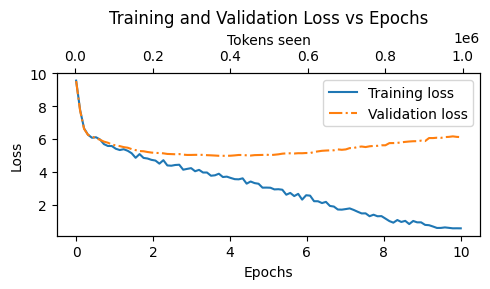

In [ ]:
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator


def plot_losses(epochs_seen, tokens_seen, train_losses, val_losses):
    fig, ax1 = plt.subplots(figsize=(5, 3))
    plt.title("Training and Validation Loss vs Epochs")

    # Plot training and validation loss against epochs
    ax1.plot(epochs_seen, train_losses, label="Training loss")
    ax1.plot(epochs_seen, val_losses, linestyle="-.", label="Validation loss")
    ax1.set_xlabel("Epochs")
    ax1.set_ylabel("Loss")
    ax1.legend(loc="upper right")
    ax1.xaxis.set_major_locator(MaxNLocator(integer=True))  # only show integer labels on x-axis

    # Create a second x-axis for tokens seen
    ax2 = ax1.twiny()  # Create a second x-axis that shares the same y-axis
    ax2.plot(tokens_seen, train_losses, alpha=0)  # Invisible plot for aligning ticks
    ax2.set_xlabel("Tokens seen")

    fig.tight_layout()  # Adjust layout to make room
    plt.savefig("images/loss_curve.png", dpi=300, bbox_inches="tight")
    plt.show()

epochs_tensor = torch.linspace(0, num_epochs, len(train_losses))
plot_losses(epochs_tensor, tokens_seen, train_losses, val_losses)

Both the training and validation losses start to improve for the first epoch. However, the losses start to diverge past the second epoch.

This divergence and the fact that the validation loss is much larger than the training loss indicate that the model is overfitting to the training data.

We can confirm that the model memorizes the training data verbatim by searching for the generated text snippets, from "Harry potter" text file.

This memorization is expected since we are working with a very, very small training dataset and training the model for multiple epochs.

Usually, it's common to train a model on a much, much larger dataset for only one epoch.

In [20]:
torch.save(model.state_dict(), "gpt2_harry_potter.pth")

### For the trained data set of combined data from The verdict, Harry Potter and Alice in the wonderland for only 3 epochs:

As we can see, the Validation loss has started to converge by the ended of the third epoch, 

If we have continued the training for more epochs, the model weights will start to overfit on the data, thats why we stopped on third epoch and saved the weights of model and optimizer state so we can continue the training on more suitable data in future.

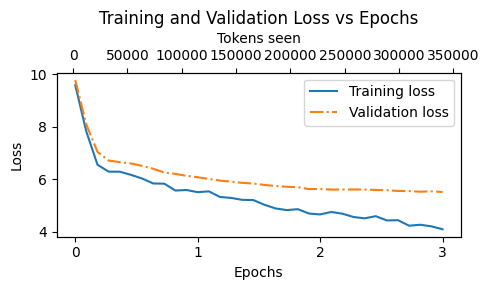

In [26]:
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator


def plot_losses(epochs_seen, tokens_seen, train_losses, val_losses):
    fig, ax1 = plt.subplots(figsize=(5, 3))
    plt.title("Training and Validation Loss vs Epochs")

    # Plot training and validation loss against epochs
    ax1.plot(epochs_seen, train_losses, label="Training loss")
    ax1.plot(epochs_seen, val_losses, linestyle="-.", label="Validation loss")
    ax1.set_xlabel("Epochs")
    ax1.set_ylabel("Loss")
    ax1.legend(loc="upper right")
    ax1.xaxis.set_major_locator(MaxNLocator(integer=True))  # only show integer labels on x-axis

    # Create a second x-axis for tokens seen
    ax2 = ax1.twiny()  # Create a second x-axis that shares the same y-axis
    ax2.plot(tokens_seen, train_losses, alpha=0)  # Invisible plot for aligning ticks
    ax2.set_xlabel("Tokens seen")

    fig.tight_layout()  # Adjust layout to make room
    plt.savefig("images/loss_curve_2.png", dpi=300, bbox_inches="tight")
    plt.show()

epochs_tensor = torch.linspace(0, num_epochs, len(train_losses))
plot_losses(epochs_tensor, tokens_seen, train_losses, val_losses)

# 03. LOADING AND SAVING MODEL WEIGHTS IN PYTORCH

Fortunately, saving a PyTorch model is relatively straightforward.

The recommended way is to save a model's so-called state_dict, a dictionary mapping each layer to its parameters, using the torch.save function as follows:

In [15]:
torch.save(model.state_dict(), "trained_weights/gpt2_combined.pth")

In the preceding code, "model.pth" is the filename where the state_dict is saved.

The .pth extension is a convention for PyTorch files, though we could technically use any file extension.

Then, after saving the model weights via the state_dict, we can load the model weights into a new GPTModel model instance as follows:

In [16]:
model = GPTModel(GPT_CONFIG_124M)
model.load_state_dict(torch.load("trained_weights/gpt2_combined.pth"))
model.eval()

GPTModel(
  (tok_emb): Embedding(50257, 768)
  (pos_emb): Embedding(1024, 768)
  (drop_emb): Dropout(p=0.1, inplace=False)
  (trf_blocks): Sequential(
    (0): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query): Linear(in_features=768, out_features=768, bias=False)
        (W_key): Linear(in_features=768, out_features=768, bias=False)
        (W_value): Linear(in_features=768, out_features=768, bias=False)
        (out_proj): Linear(in_features=768, out_features=768, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
      )
      (ff): FeedForward(
        (layers): Sequential(
          (0): Linear(in_features=768, out_features=3072, bias=True)
          (1): GELU()
          (2): Linear(in_features=3072, out_features=768, bias=True)
        )
      )
      (norm1): LayerNorm()
      (norm2): LayerNorm()
      (drop_shortcut): Dropout(p=0.1, inplace=False)
    )
    (1): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query): Linear(in_feature

If we plan to continue pretraining a model later, for example, using the train_model_simple function we defined earlier in this chapter, saving the optimizer state is also recommended.

Adaptive optimizers such as AdamW store additional parameters for each model weight. AdamW uses historical data to adjust learning rates for each model parameter dynamically.

Without it, the optimizer resets, and the model may learn suboptimally or even fail to converge properly, which means that it will lose the ability to generate coherent text.

Using torch.save, we can save both the model and optimizer state_dict contents as follows:

In [17]:
optimizer = torch.optim.AdamW(model.parameters(), lr=0.0004, weight_decay=0.1)

torch.save({
    "model_state_dict": model.state_dict(),
    "optimizer_state_dict": optimizer.state_dict(),
    }, 
    "trained_weights/gpt2_and_optimizer.pth"
)

Then, we can restore the model and optimizer states as follows by first loading the saved data via torch.load and then using the load_state_dict method:

In [18]:
checkpoint = torch.load("trained_weights/gpt2_and_optimizer.pth")
model = GPTModel(GPT_CONFIG_124M)
optimizer = torch.optim.AdamW(model.parameters(), lr=5e-4, weight_decay=0.1)
model.load_state_dict(checkpoint["model_state_dict"])
optimizer.load_state_dict(checkpoint["optimizer_state_dict"])
model.train();

Lets try to generate some text from the loaded weights:

In [21]:
model.eval()
generated_tokens = generate(
    model=model,
    idx=text_to_token_ids("Every effort moves you", tokenizer).to(device),
    max_new_tokens=50,
    context_size=model.pos_emb.weight.shape[0],
    temperature=0.8,
    top_k=10
)

In [23]:
generated_text = token_ids_to_text(generated_tokens, tokenizer)
print(generated_text.replace("\n", " "))  # Compact print format

Every effort moves you see his head.         "Oh, "What was not even they'll be able to see?" Harry, and he was a long.     "Well.      


Loading weight is fine, but our model is not good enough because we havent trained it on suited amount of data

Turns out that we can loaded the official weights of GPT-2 to our model which are released by OPEN AI

In next section, we are going to Loaded these weights from OPEN AI